# ForestSim Semantic Segmentation – Qualitative Evaluation on Spot Data

This notebook complements the ForestSim dataset exploration notebook with a qualitative, inference-only evaluation of segmentation models on real images and video captured by Boston Dynamics' Spot robot. No training or fine-tuning is performed here: the goal is to check how well models trained on synthetic data (VIS-ForestSim) or on generic datasets (Mask2Former, SegFormer) generalize to real, unstructured forest imagery acquired by Spot's onboard cameras.

Four experiments are carried out:
1. Inference with **VIS-ForestSim** (DeepLabV3, ResNet-50 backbone) on a single real image from Spot.
2. A qualitative comparison between VIS-ForestSim and **Mask2Former** (Swin-Large, ADE20K) on the same image.
3. Frame-by-frame inference with VIS-ForestSim on a **short video clip** from Spot, to assess temporal stability and runtime performance.
4. A further qualitative comparison with **SegFormer-B5** (ADE20K), used here purely as an out-of-the-box baseline with no fine-tuning, just to get a first sense of how much potential a lighter, transformer-based architecture might have.

## VIS-ForestSim Inference on a Real Spot Image

This first experiment loads the VIS-ForestSim checkpoint from Hugging Face (DeepLabV3 with a ResNet-50 backbone, 24 semantic classes) and runs inference on a single RGB frame captured by Spot's right fisheye camera. The image is resized to 512x512 for inference, and the predicted mask is then upsampled with nearest-neighbor interpolation back to the original resolution before being colorized and overlaid on the source image.

**Result.** The predicted mask is dominated by `generic_ground` (60.25%) and `tree` (35.23%), with `rock` (2.00%), `grass` (1.25%) and `sky` (0.52%) as the next most represented classes, plus small traces of `water`, `bush`, `bridge`, `concrete` and `building`. This is consistent with the qualitative behavior observed more broadly on real Spot footage: the model correctly separates trees and sky from the ground, but tends to fold most of the traversable terrain into the generic `generic_ground` class rather than distinguishing `grass` from other ground types, and it occasionally confuses rock-like textures (tree trunk bases, roots, shadowed bark) with the `rock` class.

Loading model...


Saving right_fisheye_image_20260609_143738_406.jpeg to right_fisheye_image_20260609_143738_406 (1).jpeg

Detected classes:

 0 | grass           |   1.25%
 1 | tree            |  35.23%
 3 | water           |   0.05%
 4 | sky             |   0.52%
15 | bush            |   0.01%
17 | rock            |   2.00%
18 | bridge          |   0.04%
19 | concrete        |   0.28%
21 | building        |   0.36%
23 | generic_ground  |  60.25%


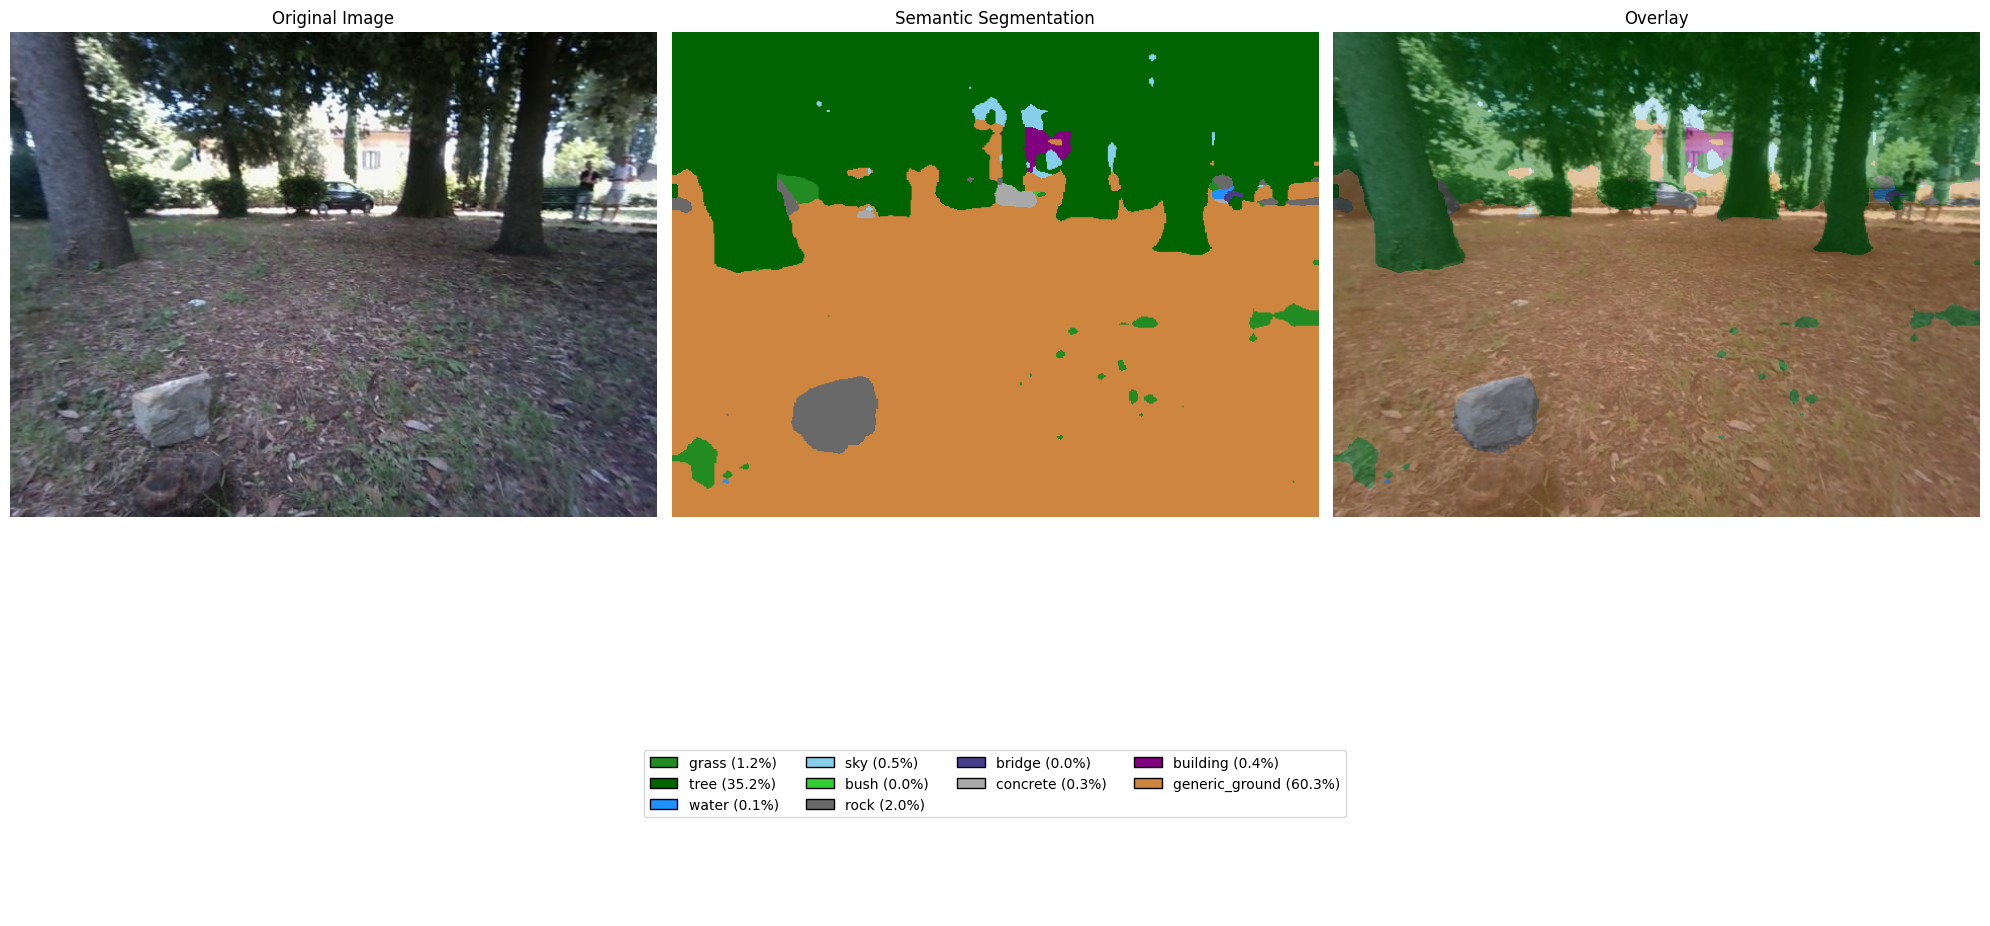

In [ ]:
# ==========================================
# VIS-FORESTSIM
# ==========================================

!pip -q install huggingface_hub

import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from huggingface_hub import hf_hub_download
from torchvision import transforms
from torchvision.models.segmentation import deeplabv3_resnet50

# --------------------------------------------------
# CONFIG
# --------------------------------------------------

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CLASSES = [
    "grass",
    "tree",
    "pole",
    "water",
    "sky",
    "vehicle",
    "container",
    "asphalt",
    "gravel",
    "mulch",
    "rockbed",
    "log",
    "bicycle",
    "person",
    "fence",
    "bush",
    "sign",
    "rock",
    "bridge",
    "concrete",
    "table",
    "building",
    "void",
    "generic_ground"
]

# RGB palette
PALETTE = np.array([
    [ 34,139, 34],  # grass
    [  0,100,  0],  # tree
    [255,255,  0],  # pole
    [ 30,144,255],  # water
    [135,206,235],  # sky
    [255,  0,  0],  # vehicle
    [255,140,  0],  # container
    [128,128,128],  # asphalt
    [210,180,140],  # gravel
    [160, 82, 45],  # mulch
    [112,128,144],  # rockbed
    [139, 69, 19],  # log
    [255, 20,147],  # bicycle
    [255,105,180],  # person
    [184,134, 11],  # fence
    [ 50,205, 50],  # bush
    [255,215,  0],  # sign
    [105,105,105],  # rock
    [ 72, 61,139],  # bridge
    [169,169,169],  # concrete
    [218,165, 32],  # table
    [128,  0,128],  # building
    [  0,  0,  0],  # void
    [205,133, 63],  # generic ground
], dtype=np.uint8)

# --------------------------------------------------
# DOWNLOAD MODEL
# --------------------------------------------------

print("Downloading checkpoint...")

ckpt_path = hf_hub_download(
    repo_id="ilessio-aiflowlab/project_vis_forestsim",
    filename="pytorch/vis_forestsim_v1.pth"
)

print("Loading model...")

model = deeplabv3_resnet50(
    num_classes=24,
    weights=None,
    weights_backbone=None
)

ckpt = torch.load(ckpt_path, map_location="cpu")

if "model" in ckpt:
    model.load_state_dict(ckpt["model"])
else:
    model.load_state_dict(ckpt)

model = model.to(DEVICE)
model.eval()

# --------------------------------------------------
# PREPROCESS
# --------------------------------------------------

from google.colab import files
uploaded = files.upload()
IMAGE_PATH = list(uploaded.keys())[0]

img = Image.open(IMAGE_PATH).convert("RGB")
orig_w, orig_h = img.size

transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),

])

x = transform(img).unsqueeze(0).to(DEVICE)

# --------------------------------------------------
# INFERENCE
# --------------------------------------------------

with torch.no_grad():
    logits = model(x)["out"]
    pred = logits.argmax(1)[0].cpu().numpy()

# --------------------------------------------------
# UPSAMPLE TO ORIGINAL SIZE
# --------------------------------------------------

mask_img = Image.fromarray(pred.astype(np.uint8))
mask_img = mask_img.resize((orig_w, orig_h), Image.NEAREST)

mask = np.array(mask_img)

# --------------------------------------------------
# COLORIZE
# --------------------------------------------------

color_mask = PALETTE[mask]

img_np = np.array(img)

overlay = (
    0.55 * img_np +
    0.45 * color_mask
).astype(np.uint8)

# --------------------------------------------------
# CLASS STATISTICS
# --------------------------------------------------

print("\nDetected classes:\n")

unique, counts = np.unique(mask, return_counts=True)

for cls, cnt in zip(unique, counts):
    perc = 100 * cnt / mask.size
    print(f"{cls:2d} | {CLASSES[cls]:15s} | {perc:6.2f}%")

# --------------------------------------------------
# VISUALIZATION + LEGEND
# --------------------------------------------------

from matplotlib.patches import Patch

present_classes = sorted(unique)

legend_elements = [
    Patch(
        facecolor=PALETTE[c] / 255.0,
        edgecolor='black',
        label=f"{CLASSES[c]} ({100*counts[list(unique).index(c)]/mask.size:.1f}%)"
    )
    for c in present_classes
]

fig = plt.figure(figsize=(20, 12))

gs = fig.add_gridspec(
    2, 3,
    height_ratios=[4, 1]
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

ax1.imshow(img_np)
ax1.set_title("Original Image")
ax1.axis("off")

ax2.imshow(color_mask)
ax2.set_title("Semantic Segmentation")
ax2.axis("off")

ax3.imshow(overlay)
ax3.set_title("Overlay")
ax3.axis("off")

legend_ax = fig.add_subplot(gs[1, :])
legend_ax.axis("off")

legend_ax.legend(
    handles=legend_elements,
    loc="center",
    ncol=4,
    fontsize=10,
    frameon=True
)

plt.tight_layout()
plt.show()




## Comparison with Mask2Former (Swin-Large, ADE20K)

To put VIS-ForestSim's behavior in context, this section runs the general-purpose Mask2Former model (Swin-Large backbone, trained on ADE20K) on the same image and displays both predictions side by side, each with its own class legend.

The two models show complementary strengths: VIS-ForestSim, being trained specifically on forest-like synthetic scenes, produces a more coherent and detailed segmentation of the tree canopy and vegetation structure, while Mask2Former — trained on a generic, object-centric dataset — is better at recognizing man-made elements (e.g. vehicles, fences, benches) that are not explicitly represented as separate classes in ForestSim. Mask2Former also tends to label grassy ground as `grass` more readily, whereas VIS-ForestSim leans toward the catch-all `generic_ground` class.

Installing missing dependencies for Mask2Former...


Loading Mask2Former (Swin-Large)...


preprocessor_config.json:   0%|          | 0.00/538 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/82.5k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/866M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/758 [00:00<?, ?it/s]

[transformers] Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-large-ade-semantic
Key                                                                                                                      | Status     | 
-------------------------------------------------------------------------------------------------------------------------+------------+-
model.pixel_level_module.encoder.swin.encoder.layers.{0, 1, 2, 3}.blocks.{0...17}.attention.self.relative_position_index | UNEXPECTED | 
model.pixel_level_module.encoder.swin.layernorm.weight                                                                   | MISSING    | 
model.pixel_level_module.encoder.swin.layernorm.bias                                                                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

Running inference on Mask2Former...
Generating comparison plot...


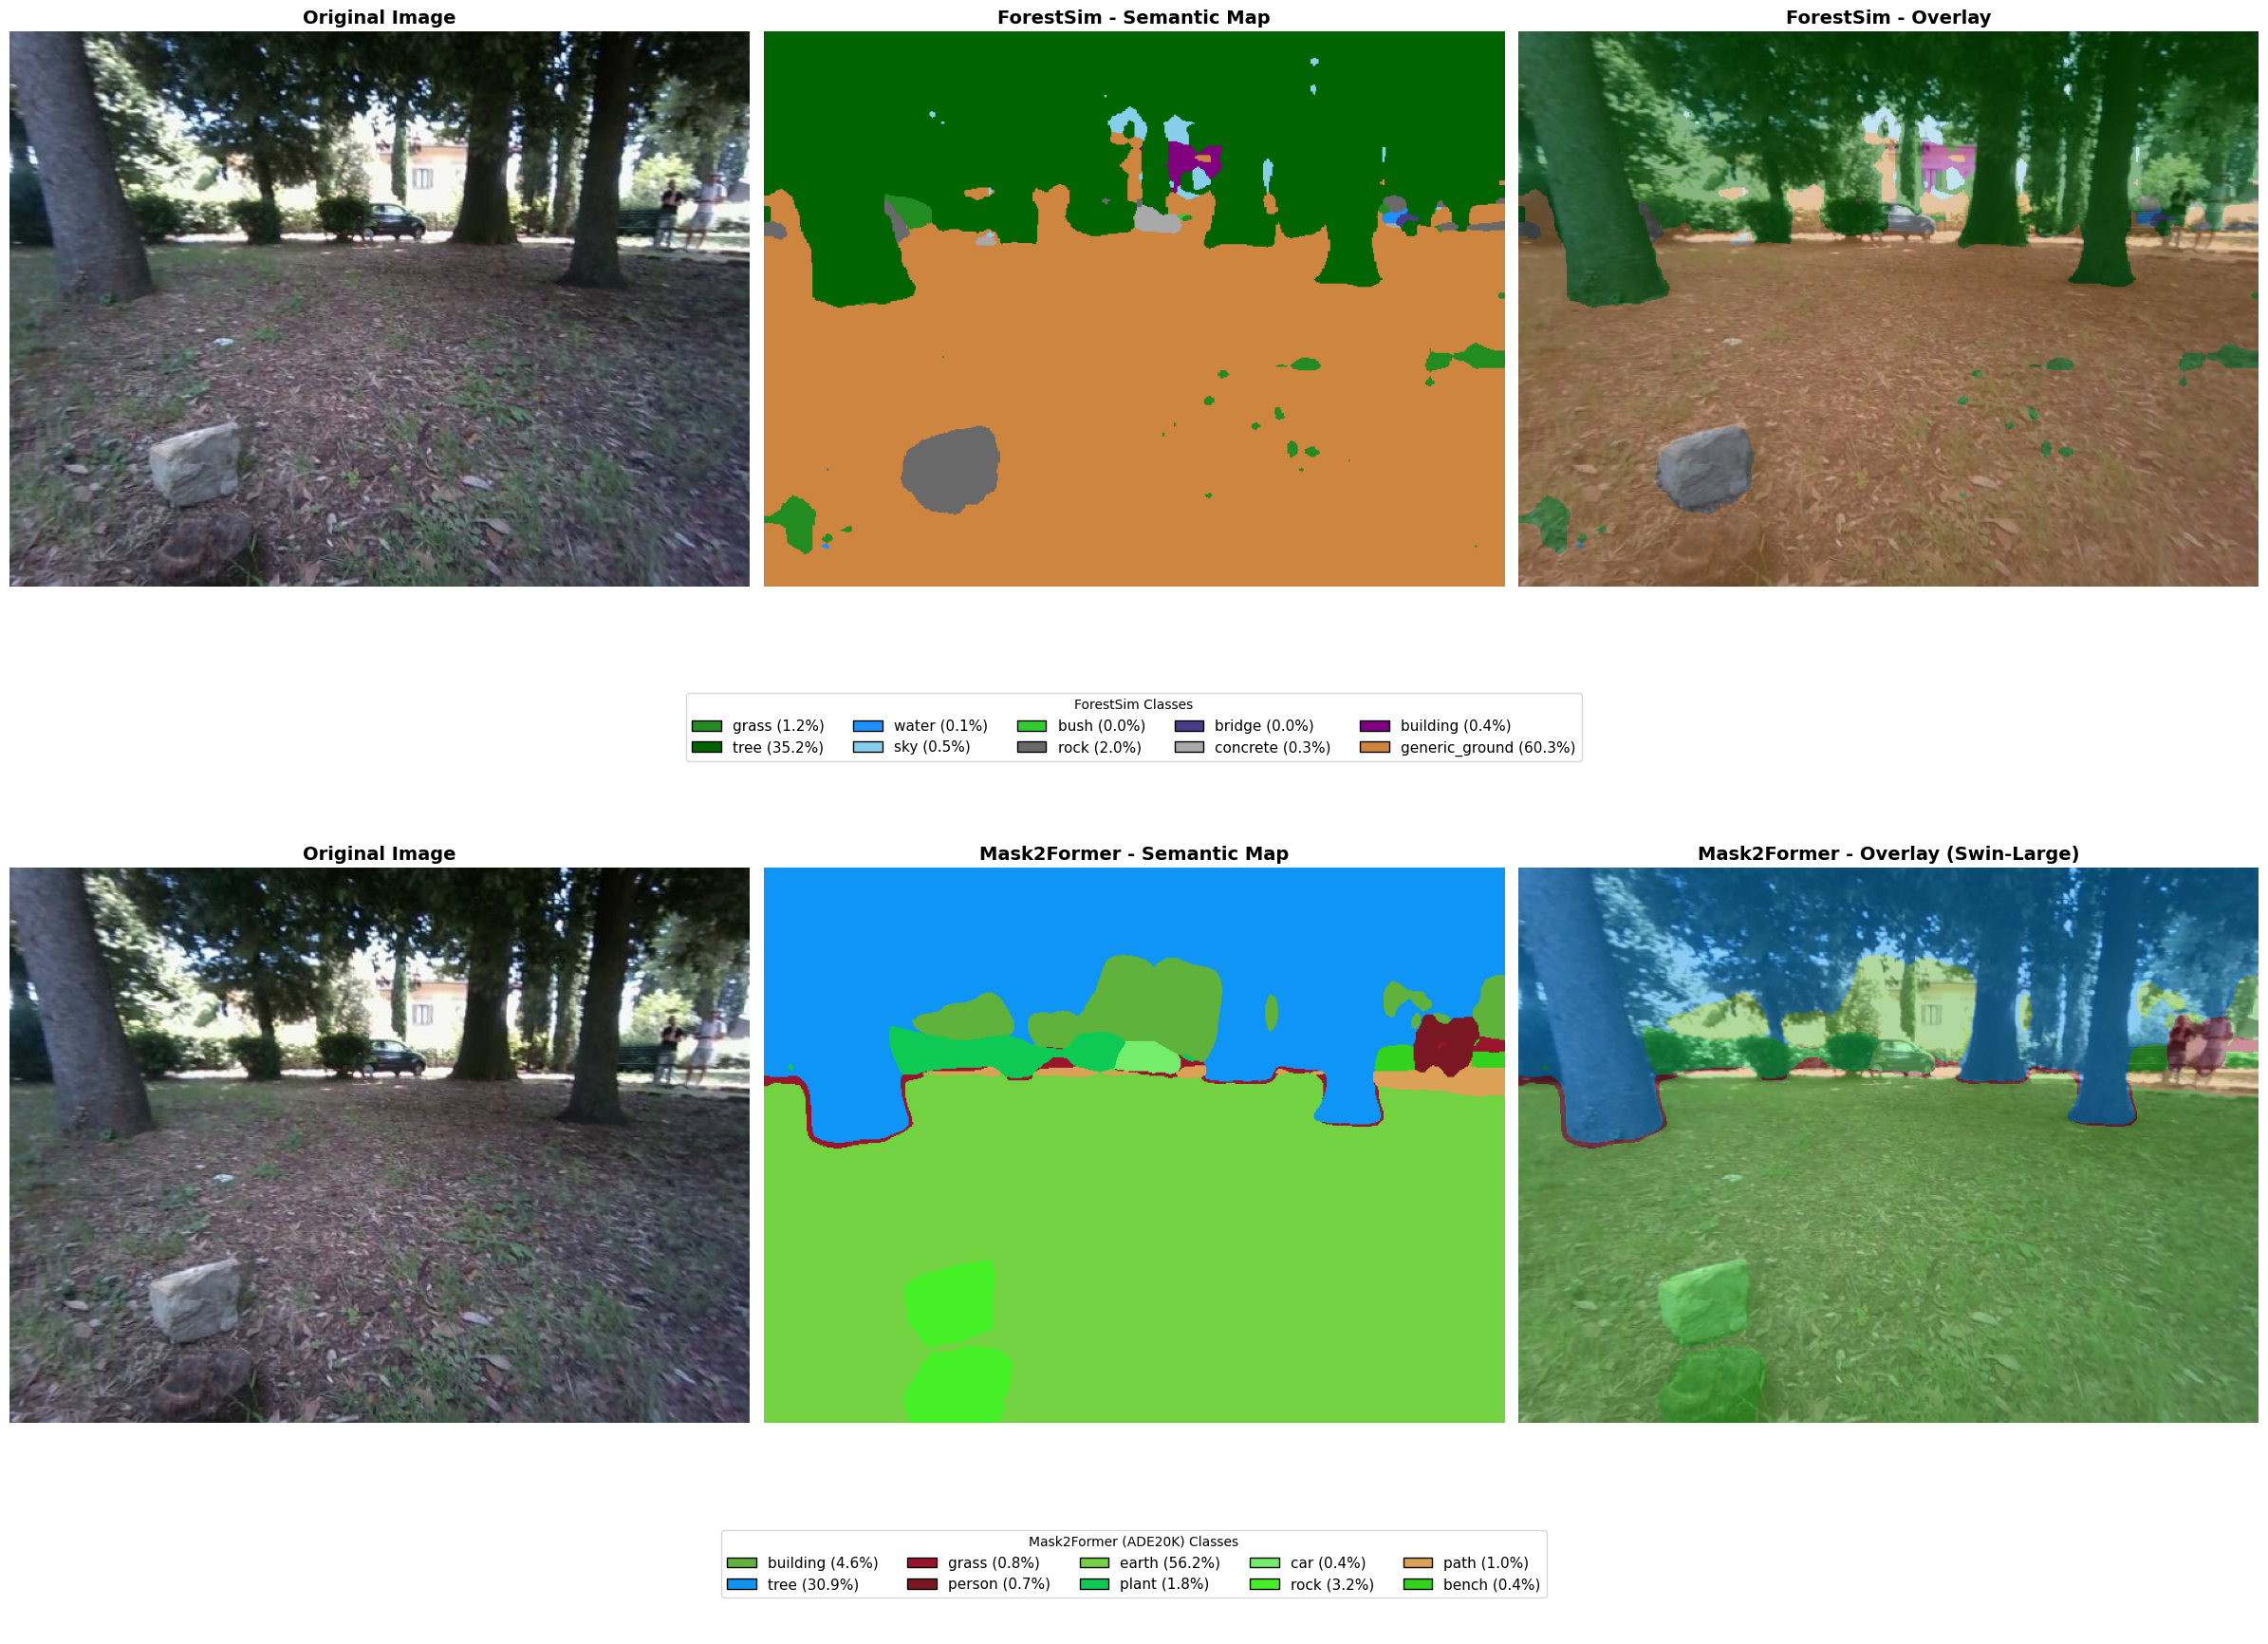

In [ ]:
# ==========================================
# COMPARISON: FORESTSIM VS MASK2FORMER (WITH LEGENDS)
# ==========================================

print("Installing missing dependencies for Mask2Former...")
!pip -q install transformers accelerate

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.patches import Patch
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Load Mask2Former
print("Loading Mask2Former (Swin-Large)...")
processor = AutoImageProcessor.from_pretrained("facebook/mask2former-swin-large-ade-semantic")
m2f_model = Mask2FormerForUniversalSegmentation.from_pretrained("facebook/mask2former-swin-large-ade-semantic")
m2f_model = m2f_model.to(DEVICE)
m2f_model.eval()

try:
    _ = img.size
except NameError:
    img = Image.open(IMAGE_PATH).convert("RGB")

orig_w, orig_h = img.size

print("Running inference on Mask2Former...")
inputs = processor(images=img, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    outputs = m2f_model(**inputs)

predicted_semantic_map = processor.post_process_semantic_segmentation(
    outputs,
    target_sizes=[(orig_h, orig_w)]
)[0]

m2f_mask = predicted_semantic_map.cpu().numpy()

#
labels_info = m2f_model.config.id2label
num_classes_m2f = len(labels_info)

# Fixed palette for consistent coloring
np.random.seed(42)
m2f_palette = np.random.randint(0, 255, size=(num_classes_m2f, 3), dtype=np.uint8)
if 0 in labels_info: m2f_palette[0] = [0, 0, 0]

m2f_color_mask = m2f_palette[m2f_mask]

img_np = np.array(img)
m2f_overlay = (0.55 * img_np + 0.45 * m2f_color_mask).astype(np.uint8)

# Compute detected Mask2Former classes for the legend
m2f_unique, m2f_counts = np.unique(m2f_mask, return_counts=True)
m2f_present_classes = sorted(m2f_unique)

m2f_legend_elements = [
    Patch(
        facecolor=m2f_palette[c] / 255.0,
        edgecolor='black',
        label=f"{labels_info[c]} ({100*m2f_counts[list(m2f_unique).index(c)]/m2f_mask.size:.1f}%)"
    )
    for c in m2f_present_classes
]

# RETRIEVE FORESTSIM DATA (from the previous cell)
try:
    forestsim_overlay = overlay
    forestsim_mask_color = color_mask
    forestsim_legend_elements = legend_elements
except NameError:
    print("[WARNING] ForestSim data not found. Showing only Mask2Former.")
    forestsim_overlay = None

# ==========================================
# COMPARATIVE VISUALIZATION WITH LEGENDS
# ==========================================

print("Generating comparison plot...")

if forestsim_overlay is not None:
    # Grid layout: 2 rows of images + 2 thin rows for the respective legends
    fig = plt.figure(figsize=(24, 18))
    gs = fig.add_gridspec(4, 3, height_ratios=[4, 0.8, 4, 0.8])

    # --- ROW 1: ForestSim Images ---
    ax_f1 = fig.add_subplot(gs[0, 0])
    ax_f1.imshow(img_np)
    ax_f1.set_title("Original Image", fontsize=14, fontweight='bold')
    ax_f1.axis("off")

    ax_f2 = fig.add_subplot(gs[0, 1])
    ax_f2.imshow(forestsim_mask_color)
    ax_f2.set_title("ForestSim - Semantic Map", fontsize=14, fontweight='bold')
    ax_f2.axis("off")

    ax_f3 = fig.add_subplot(gs[0, 2])
    ax_f3.imshow(forestsim_overlay)
    ax_f3.set_title("ForestSim - Overlay", fontsize=14, fontweight='bold')
    ax_f3.axis("off")

    # --- ROW 2: ForestSim Legend ---
    legend_f_ax = fig.add_subplot(gs[1, :])
    legend_f_ax.axis("off")
    legend_f_ax.legend(
        handles=forestsim_legend_elements,
        loc="center", ncol=5, fontsize=11, frameon=True, title="ForestSim Classes"
    )

    # --- ROW 3: Mask2Former Images ---
    ax_m1 = fig.add_subplot(gs[2, 0])
    ax_m1.imshow(img_np)
    ax_m1.set_title("Original Image", fontsize=14, fontweight='bold')
    ax_m1.axis("off")

    ax_m2 = fig.add_subplot(gs[2, 1])
    ax_m2.imshow(m2f_color_mask)
    ax_m2.set_title("Mask2Former - Semantic Map", fontsize=14, fontweight='bold')
    ax_m2.axis("off")

    ax_m3 = fig.add_subplot(gs[2, 2])
    ax_m3.imshow(m2f_overlay)
    ax_m3.set_title("Mask2Former - Overlay (Swin-Large)", fontsize=14, fontweight='bold')
    ax_m3.axis("off")

    # --- ROW 4: Mask2Former Legend ---
    legend_m_ax = fig.add_subplot(gs[3, :])
    legend_m_ax.axis("off")
    legend_m_ax.legend(
        handles=m2f_legend_elements,
        loc="center", ncol=5, fontsize=11, frameon=True, title="Mask2Former (ADE20K) Classes"
    )

else:
    # Fallback if ForestSim data is not present
    fig = plt.figure(figsize=(24, 10))
    gs = fig.add_gridspec(2, 3, height_ratios=[4, 1])

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(img_np)
    ax1.axis("off")

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.imshow(m2f_color_mask)
    ax2.set_title("Mask2Former - Semantic Map", fontsize=14)
    ax2.axis("off")

    ax3 = fig.add_subplot(gs[0, 2])
    ax3.imshow(m2f_overlay)
    ax3.set_title("Mask2Former - Overlay", fontsize=14)
    ax3.axis("off")

    legend_ax = fig.add_subplot(gs[1, :])
    legend_ax.axis("off")
    legend_ax.legend(handles=m2f_legend_elements, loc="center", ncol=5, fontsize=11, frameon=True)

plt.tight_layout()
plt.show()

## Video Inference: Temporal Consistency and Runtime Performance

This experiment applies VIS-ForestSim frame-by-frame to a short video clip recorded by Spot, to evaluate two aspects that a single-image test cannot capture: the temporal stability of the predicted masks across consecutive frames, and the runtime performance of the model on a real GPU.

Each frame is processed independently (no temporal smoothing), and the resulting segmentation and overlay videos are exported, together with down-sampled GIF previews for quick visual inspection directly in the notebook.

**Result.** On an NVIDIA T4 GPU, the 640x480, 80-frame clip (recorded at ~10.04 FPS) is processed in 11.24 s, corresponding to an average inference time of 140.44 ms/frame, i.e. ~7.12 FPS — below the source video's frame rate, so the model does not currently run in real time on this hardware. Qualitatively, the predictions are fairly stable over time: the ground is consistently classified as `generic_ground`, and most flickering is limited to small grass tufts near the camera, which are intermittently classified as `grass` due to lighting changes between frames. A more interesting effect appears on partially shaded background vegetation, where the illuminated part of a hedge is stably classified as `tree` while the shaded part is frequently mislabeled as `generic_ground` — suggesting the model is sensitive to illumination and low-contrast textures. This runtime result is an important data point for the thesis: even the teacher network alone is not real-time on embedded-class hardware, which reinforces the motivation for training a lighter, distilled student model for on-robot deployment.

In [ ]:
# ==========================================
# VIS-FORESTSIM VIDEO SEGMENTATION + GIF PREVIEW
# ==========================================

!pip -q install huggingface_hub opencv-python imageio

import cv2
import time
import torch
import imageio.v2 as imageio
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files
from huggingface_hub import hf_hub_download
from torchvision import transforms
from torchvision.models.segmentation import deeplabv3_resnet50

from IPython.display import HTML, display
from base64 import b64encode

# --------------------------------------------------
# CONFIG
# --------------------------------------------------

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MAX_GIF_FRAMES = 150

CLASSES = [
    "grass","tree","pole","water","sky","vehicle",
    "container","asphalt","gravel","mulch","rockbed",
    "log","bicycle","person","fence","bush","sign",
    "rock","bridge","concrete","table","building",
    "void","generic_ground"
]

PALETTE = np.array([
    [ 34,139, 34],  # grass
    [  0,100,  0],  # tree
    [255,255,  0],  # pole
    [ 30,144,255],  # water
    [135,206,235],  # sky
    [255,  0,  0],  # vehicle
    [255,140,  0],  # container
    [128,128,128],  # asphalt
    [210,180,140],  # gravel
    [160, 82, 45],  # mulch
    [112,128,144],  # rockbed
    [139, 69, 19],  # log
    [255, 20,147],  # bicycle
    [255,105,180],  # person
    [184,134, 11],  # fence
    [ 50,205, 50],  # bush
    [255,215,  0],  # sign
    [105,105,105],  # rock
    [ 72, 61,139],  # bridge
    [169,169,169],  # concrete
    [218,165, 32],  # table
    [128,  0,128],  # building
    [  0,  0,  0],  # void
    [205,133, 63],  # generic ground
], dtype=np.uint8)

# --------------------------------------------------
# LOAD MODEL
# --------------------------------------------------

print("Downloading checkpoint...")

ckpt_path = hf_hub_download(
    repo_id="ilessio-aiflowlab/project_vis_forestsim",
    filename="pytorch/vis_forestsim_v1.pth"
)

print("Loading model...")

model = deeplabv3_resnet50(
    num_classes=24,
    weights=None,
    weights_backbone=None
)

ckpt = torch.load(ckpt_path, map_location="cpu")

if "model" in ckpt:
    model.load_state_dict(ckpt["model"])
else:
    model.load_state_dict(ckpt)

model = model.to(DEVICE)
model.eval()

print(f"Model loaded on {DEVICE}")

# --------------------------------------------------
# VIDEO UPLOAD
# --------------------------------------------------

uploaded = files.upload()
VIDEO_PATH = list(uploaded.keys())[0]

cap = cv2.VideoCapture(VIDEO_PATH)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Resolution : {width}x{height}")
print(f"FPS        : {fps:.2f}")
print(f"Frames     : {total_frames}")

# --------------------------------------------------
# OUTPUT VIDEOS
# --------------------------------------------------

overlay_writer = cv2.VideoWriter(
    "forestsim_overlay.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)

mask_writer = cv2.VideoWriter(
    "forestsim_mask.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)

# --------------------------------------------------
# PREPROCESS
# --------------------------------------------------

transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
])

# --------------------------------------------------
# GIF SAMPLING
# --------------------------------------------------

sample_step = max(1, total_frames // MAX_GIF_FRAMES)

orig_gif = []
mask_gif = []
overlay_gif = []

# --------------------------------------------------
# INFERENCE
# --------------------------------------------------

start_time = time.time()

frame_idx = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    pil_img = Image.fromarray(rgb)

    x = transform(pil_img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(x)["out"]
        pred = logits.argmax(1)[0].cpu().numpy()

    mask = Image.fromarray(pred.astype(np.uint8))
    mask = mask.resize((width, height), Image.NEAREST)
    mask = np.array(mask)

    color_mask = PALETTE[mask]

    overlay = (
        0.55 * rgb +
        0.45 * color_mask
    ).astype(np.uint8)

    overlay_writer.write(
        cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
    )

    mask_writer.write(
        cv2.cvtColor(color_mask, cv2.COLOR_RGB2BGR)
    )

    if frame_idx % sample_step == 0:

        orig_gif.append(rgb)

        mask_gif.append(color_mask)

        overlay_gif.append(overlay)

    frame_idx += 1

    if frame_idx % 50 == 0:
        print(f"{frame_idx}/{total_frames}")

cap.release()
overlay_writer.release()
mask_writer.release()

# --------------------------------------------------
# PERFORMANCE
# --------------------------------------------------

total_time = time.time() - start_time

effective_fps = frame_idx / total_time
ms_per_frame = 1000.0 / effective_fps

# --------------------------------------------------
# CREATE GIFS
# --------------------------------------------------

print("\nCreating GIF previews...")

gif_fps = min(10, fps)

imageio.mimsave(
    "original.gif",
    orig_gif,
    fps=gif_fps
)

imageio.mimsave(
    "mask.gif",
    mask_gif,
    fps=gif_fps
)

imageio.mimsave(
    "overlay.gif",
    overlay_gif,
    fps=gif_fps
)

# --------------------------------------------------
# PERFORMANCE REPORT
# --------------------------------------------------

print("\n==============================")
print("PERFORMANCE REPORT")
print("==============================")

print(f"Device           : {DEVICE}")
print(f"Resolution       : {width} x {height}")
print(f"Frames           : {frame_idx}")
print(f"Video FPS        : {fps:.2f}")

print(f"\nTotal Time       : {total_time:.2f} s")
print(f"Inference FPS    : {effective_fps:.2f}")
print(f"Time / Frame     : {ms_per_frame:.2f} ms")

if effective_fps >= fps:
    print("\nReal-time capable ✓")
else:
    print("\nNot real-time ✗")

# --------------------------------------------------
# DISPLAY GIFS
# --------------------------------------------------

def show_gif(path, width=450):

    data_url = b64encode(
        open(path, "rb").read()
    ).decode()

    return HTML(
        f'<img src="data:image/gif;base64,{data_url}" width="{width}">'
    )

print("\nORIGINAL VIDEO")
display(show_gif("original.gif"))

print("\nSEGMENTATION")
display(show_gif("mask.gif"))

print("\nOVERLAY")
display(show_gif("overlay.gif"))



### Exporting Frames for Further Analysis

The GIF previews generated above are split back into individual PNG frames and packed into zip archives (original / mask / overlay), to make it easier to inspect specific frames outside Colab or to reuse them for other analyses.

In [ ]:
from PIL import Image
import os
import shutil
from google.colab import files

def gif_to_frames(gif_path, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    gif = Image.open(gif_path)

    frame = 0
    while True:
        try:
            gif.seek(frame)

            gif.convert("RGB").save(
                os.path.join(output_dir, f"frame_{frame:03d}.png")
            )

            frame += 1

        except EOFError:
            break

    print(f"Extracted {frame} frames in {output_dir}")

gif_to_frames("original.gif", "frames_original")
gif_to_frames("mask.gif", "frames_mask")
gif_to_frames("overlay.gif", "frames_overlay")

folders_to_download = ["frames_original", "frames_mask", "frames_overlay"]

for folder in folders_to_download:
    archive_name = shutil.make_archive(folder, 'zip', folder)
    files.download(archive_name)


Estratti 80 frame in frames_original
Estratti 80 frame in frames_mask
Estratti 80 frame in frames_overlay


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Comparison with SegFormer Baselines (B0, B1 and B5)

As a further point of comparison, this section evaluates three SegFormer variants — **SegFormer-B0**, **SegFormer-B1**, and **SegFormer-B5** — on the same image, using the publicly available ADE20K-pretrained checkpoints:

- **SegFormer-B0** (`nvidia/segformer-b0-finetuned-ade-512-512`, ~3.8M parameters)
- **SegFormer-B1** (`nvidia/segformer-b1-finetuned-ade-512-512`, ~13.7M parameters)
- **SegFormer-B5** (`nvidia/segformer-b5-finetuned-ade-640-640`, ~84M parameters)

Each model is evaluated **out of the box**, without any fine-tuning on ForestSim or Spot data. Predictions are visualized using a random color palette and the original ADE20K class labels, following the same qualitative setup adopted for the previous Mask2Former comparison.

Since the SegFormer models were not adapted to the ForestSim class taxonomy, a direct quantitative comparison with VIS-ForestSim is not meaningful. Instead, the results should be interpreted qualitatively, focusing on how well each model captures object boundaries, vegetation structure, and the overall scene layout.

Comparing the three variants also provides insight into the **quality–size–speed trade-off**. While SegFormer-B5 represents the highest-capacity model, the much smaller B0 and B1 variants are particularly attractive for real-time deployment on Spot, where computational efficiency is a key requirement. Together with MobileNetV3 and EfficientNet, these lightweight transformer backbones represent promising candidates for future student models distilled from VIS-ForestSim.

The cell below runs the three SegFormer variants on the same input image, reports the number of parameters and inference time for each model, and displays their predictions side by side to enable a qualitative comparison of segmentation quality versus computational cost.


Running SegFormer-B0...

Loading nvidia/segformer-b0-finetuned-ade-512-512...


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]


Running SegFormer-B1...

Loading nvidia/segformer-b1-finetuned-ade-512-512...


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]


Running SegFormer-B5...

Loading nvidia/segformer-b5-finetuned-ade-640-640...


Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]


MODEL COMPARISON
Model             Params (M)       Inference
SegFormer-B0            3.8           46.4 ms
SegFormer-B1           13.7           27.6 ms
SegFormer-B5           84.7          121.7 ms


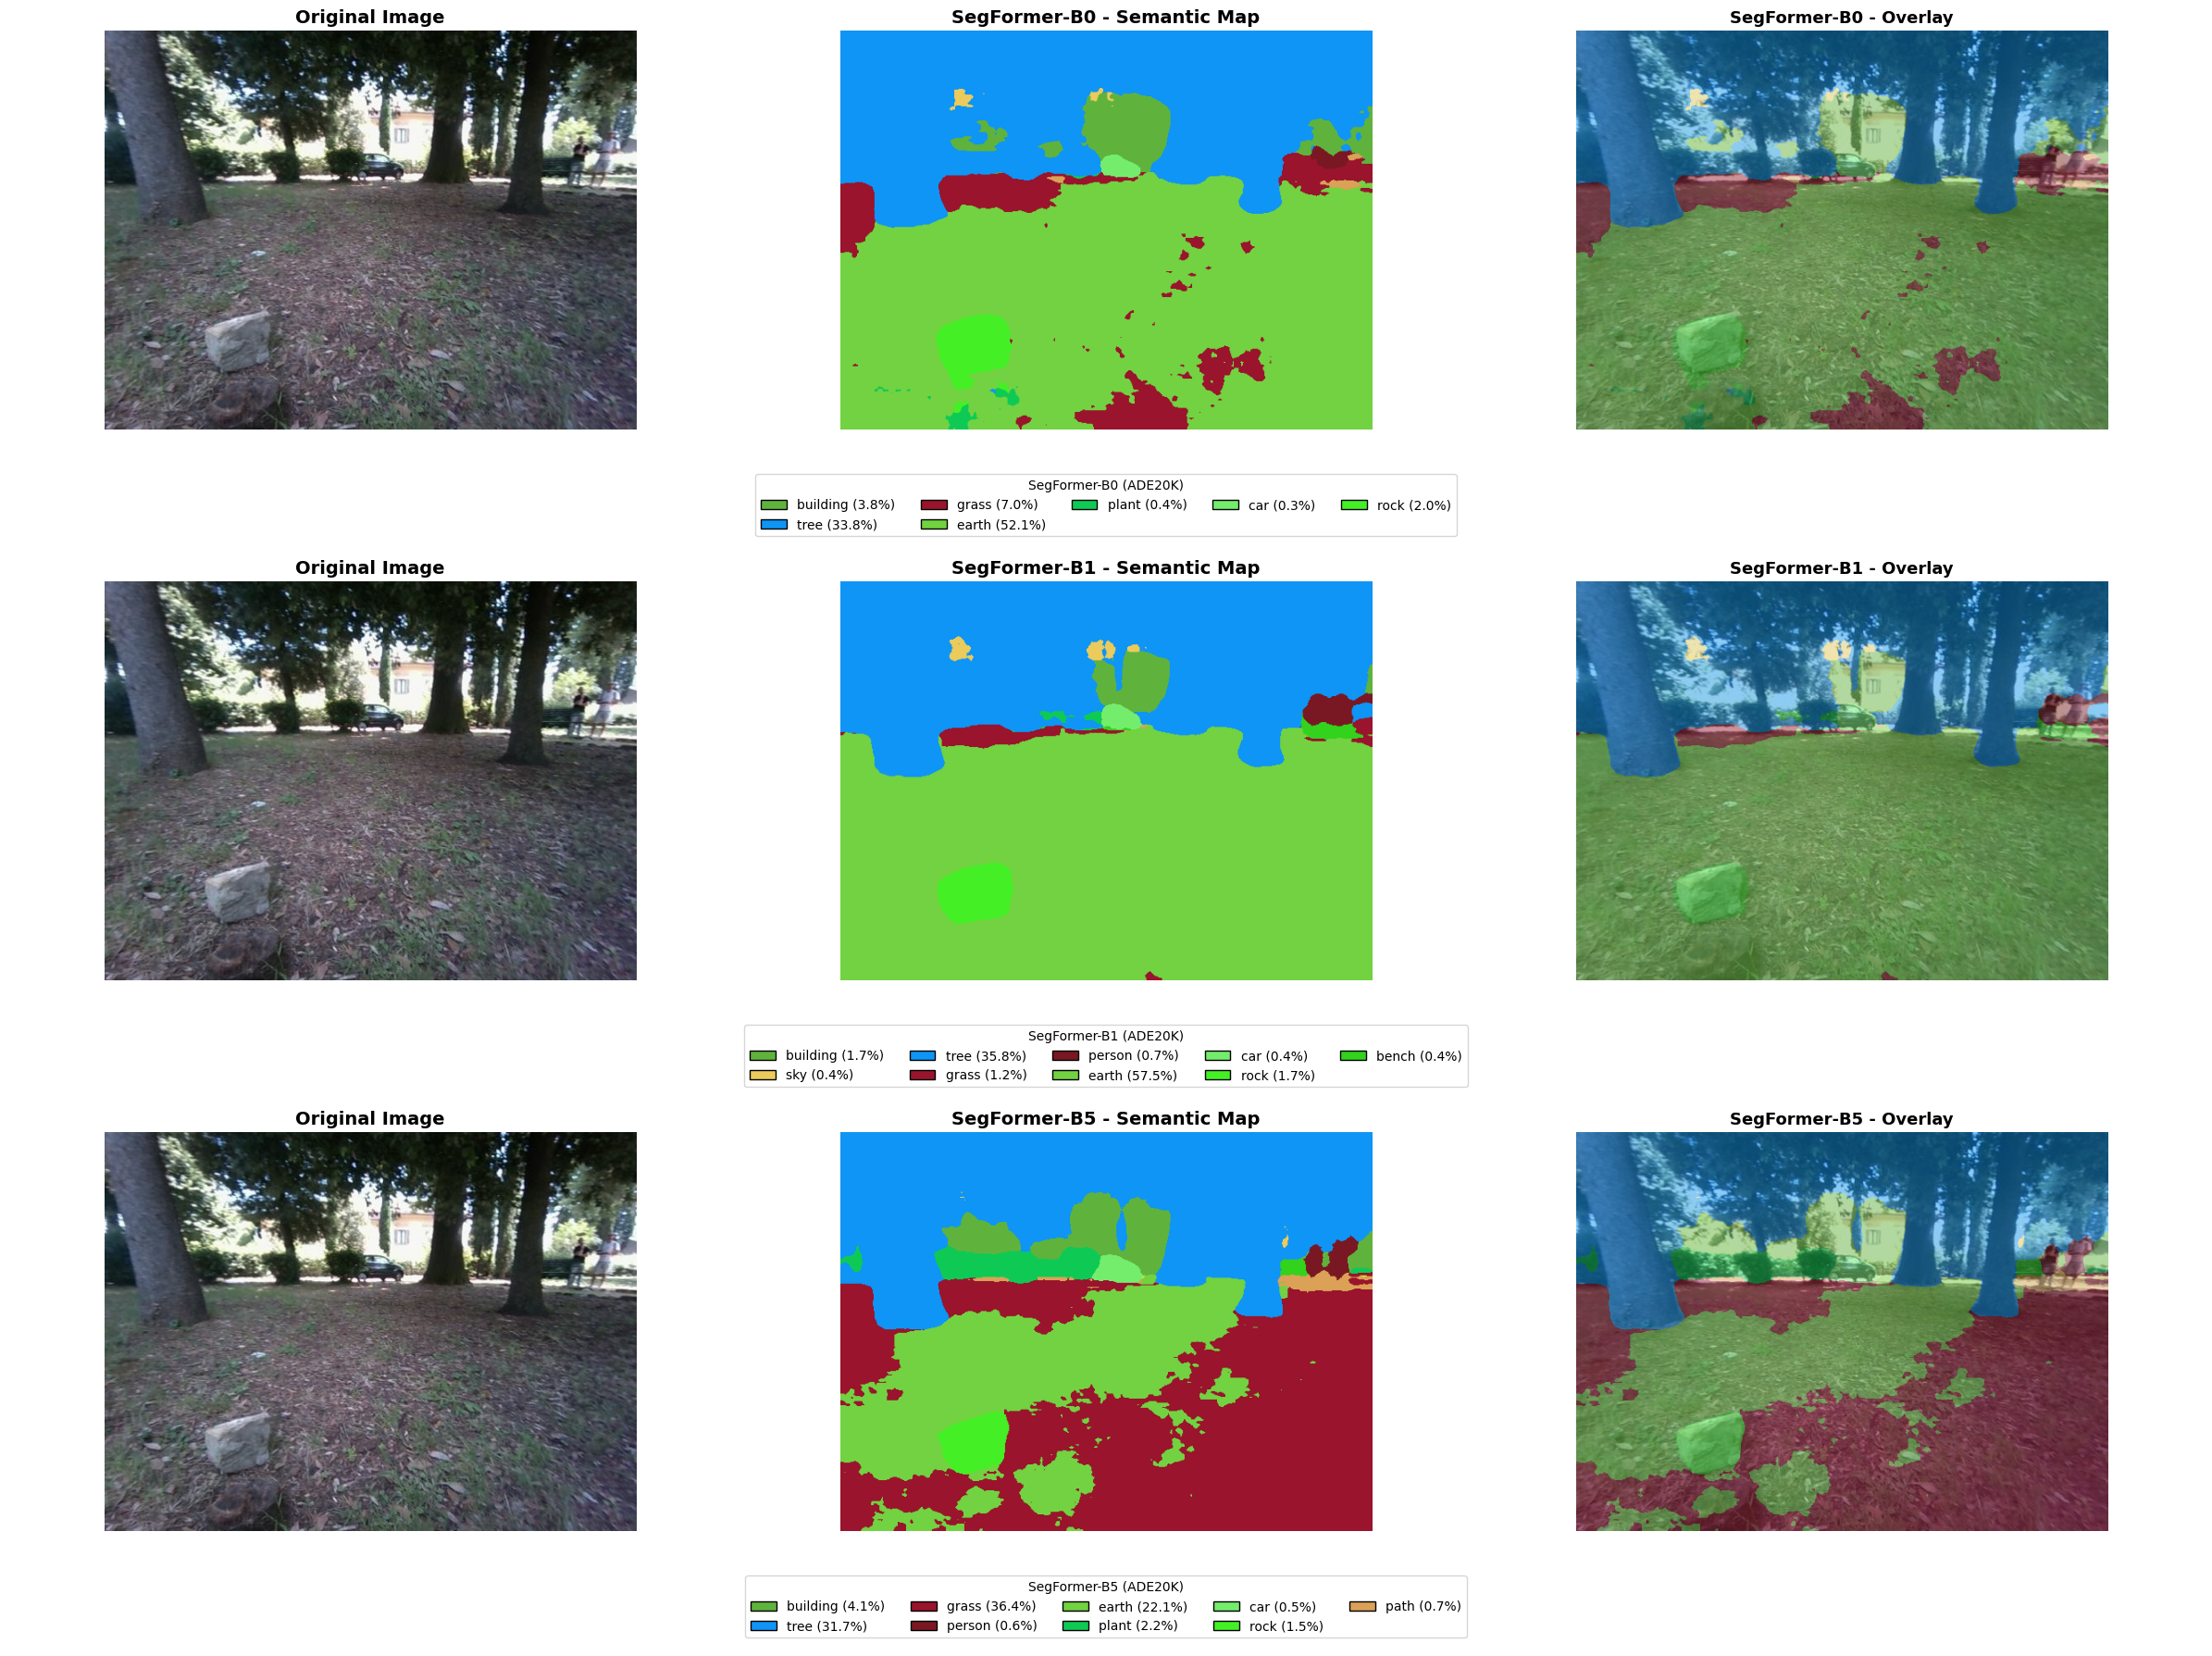

In [6]:
# ==========================================
# COMPARISON: SegFormer-B0 vs B1 vs B5
# ==========================================

!pip -q install transformers accelerate

import time
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from matplotlib.patches import Patch
from transformers import (
    SegformerImageProcessor,
    SegformerForSemanticSegmentation,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --------------------------------------------------
# IMAGE
# --------------------------------------------------

try:
    _ = img.size
except NameError:
    img = Image.open(IMAGE_PATH).convert("RGB")

img_np = np.array(img)
orig_w, orig_h = img.size

# --------------------------------------------------
# MODELS
# --------------------------------------------------

MODELS = {
    "SegFormer-B0": "nvidia/segformer-b0-finetuned-ade-512-512",
    "SegFormer-B1": "nvidia/segformer-b1-finetuned-ade-512-512",
    "SegFormer-B5": "nvidia/segformer-b5-finetuned-ade-640-640",
}

# --------------------------------------------------
# INFERENCE FUNCTION
# --------------------------------------------------

def run_segformer(model_name, image, seed=42):

    print(f"\nLoading {model_name}...")

    processor = SegformerImageProcessor.from_pretrained(model_name)

    model = SegformerForSemanticSegmentation.from_pretrained(
        model_name
    ).to(DEVICE)

    model.eval()

    n_params = sum(p.numel() for p in model.parameters())

    inputs = processor(
        images=image,
        return_tensors="pt"
    ).to(DEVICE)

    torch.cuda.empty_cache()

    start = time.time()

    with torch.no_grad():
        outputs = model(**inputs)

    inference_time = time.time() - start

    logits = torch.nn.functional.interpolate(
        outputs.logits,
        size=(orig_h, orig_w),
        mode="bilinear",
        align_corners=False
    )

    mask = logits.argmax(dim=1)[0].cpu().numpy()

    labels_info = model.config.id2label
    num_classes = len(labels_info)

    np.random.seed(seed)

    palette = np.random.randint(
        0,
        255,
        size=(num_classes, 3),
        dtype=np.uint8
    )

    if 0 in labels_info:
        palette[0] = [0, 0, 0]

    color_mask = palette[mask]

    overlay = (
        0.55 * img_np +
        0.45 * color_mask
    ).astype(np.uint8)

    unique, counts = np.unique(
        mask,
        return_counts=True
    )

    legend_elements = []

    for c, cnt in zip(unique, counts):

        perc = 100 * cnt / mask.size

        if perc > 0.3:

            legend_elements.append(

                Patch(
                    facecolor=palette[c] / 255.0,
                    edgecolor="black",
                    label=f"{labels_info[c]} ({perc:.1f}%)"
                )

            )

    return {
        "mask": mask,
        "color_mask": color_mask,
        "overlay": overlay,
        "legend": legend_elements,
        "params": n_params,
        "time": inference_time,
    }

# --------------------------------------------------
# RUN ALL MODELS
# --------------------------------------------------

results = {}

for label, model_name in MODELS.items():

    print(f"\nRunning {label}...")

    results[label] = run_segformer(model_name, img)

# --------------------------------------------------
# SUMMARY
# --------------------------------------------------

print("\n============================================")
print("MODEL COMPARISON")
print("============================================")

print(f"{'Model':15s} {'Params (M)':>12s} {'Inference':>15s}")

for label, r in results.items():

    print(
        f"{label:15s}"
        f"{r['params']/1e6:12.1f}"
        f"{1000*r['time']:15.1f} ms"
    )

# --------------------------------------------------
# VISUALIZATION
# --------------------------------------------------

n_models = len(results)

fig = plt.figure(
    figsize=(24, 6 * n_models)
)

gs = fig.add_gridspec(
    2 * n_models,
    3,
    height_ratios=sum([[4, 0.8] for _ in range(n_models)], [])
)

for i, (label, r) in enumerate(results.items()):

    row = 2 * i

    ax1 = fig.add_subplot(gs[row, 0])
    ax1.imshow(img_np)
    ax1.set_title(
        "Original Image",
        fontsize=14,
        fontweight="bold"
    )
    ax1.axis("off")

    ax2 = fig.add_subplot(gs[row, 1])
    ax2.imshow(r["color_mask"])
    ax2.set_title(
        f"{label} - Semantic Map",
        fontsize=14,
        fontweight="bold"
    )
    ax2.axis("off")

    ax3 = fig.add_subplot(gs[row, 2])
    ax3.imshow(r["overlay"])
    ax3.set_title(
        f"{label} - Overlay",
        fontsize=13,
        fontweight="bold"
    )
    ax3.axis("off")

    legend_ax = fig.add_subplot(gs[row + 1, :])

    legend_ax.axis("off")

    legend_ax.legend(
        handles=r["legend"],
        loc="center",
        ncol=5,
        fontsize=10,
        frameon=True,
        title=f"{label} (ADE20K)"
    )

plt.tight_layout()
plt.show()